In [48]:
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import timeit
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Automated histogram plot settings
xmin, xmax = -10, 10
num_bins = 100

def plot_histogram(counts, xmin=xmin, xmax=xmax, num_bins=num_bins, method_name="Method"):
    # Map bin counts to x-range [-10, 10]
    bin_width = (xmax - xmin) / num_bins
    x_left_edges = [xmin + i * bin_width for i in range(num_bins)]

    plt.figure(figsize=(10, 4))
    plt.bar(x_left_edges, counts, width=bin_width, align="edge", edgecolor="black")
    plt.xlim(xmin, xmax)
    plt.title(f"{method_name}: Histogram (x from {xmin} to {xmax}, {num_bins} bins)")
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def plot_strong_scaling(n, thread_counts, times, errors=None, method_name="Method"):
    plt.figure(figsize=(7, 4))
    if errors is not None:
        plt.errorbar(thread_counts, times, yerr=errors, marker='o', capsize=5, capthick=2)
    else:
        plt.plot(thread_counts, times, marker='o')
    plt.title(f"{method_name}: Strong Scaling: Runtime vs Number of Threads for n = 1e{int(np.log10(n))}")
    plt.xlabel("Number of Threads")
    plt.ylabel("Runtime (seconds)")
    plt.xticks(thread_counts)
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_weak_scaling(n, thread_counts, times, errors=None, method_name="Method"):
    plt.figure(figsize=(7, 4))
    if errors is not None:
        plt.errorbar(thread_counts, times, yerr=errors, marker='o', capsize=5, capthick=2)
    else:
        plt.plot(thread_counts, times, marker='o')
    plt.title(f"{method_name}: Weak Scaling: Runtime vs Number of Threads for n = 1e{int(np.log10(n))} per thread")
    plt.xlabel("Number of Threads")
    plt.ylabel("Runtime (seconds)")
    plt.xticks(thread_counts)
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_speedup(thread_counts, speedup, speedup_errors=None, method_name="Method"):
    plt.figure(figsize=(7, 4))
    if speedup_errors is not None:
        plt.errorbar(thread_counts, speedup, yerr=speedup_errors, marker='o', capsize=5, capthick=2)
    else:
        plt.plot(thread_counts, speedup, marker='o')
    plt.xscale('log', base=10)
    plt.yscale('log', base=2)
    plt.xlabel('Number of Threads (log scale)')
    plt.ylabel('Speedup')
    plt.title(f'{method_name}: Speedup vs Number of Threads')
    plt.grid(True, which="both", ls="--")
    plt.xticks(thread_counts, thread_counts)
    plt.tight_layout()
    plt.show()


# Testing with visualize histogram

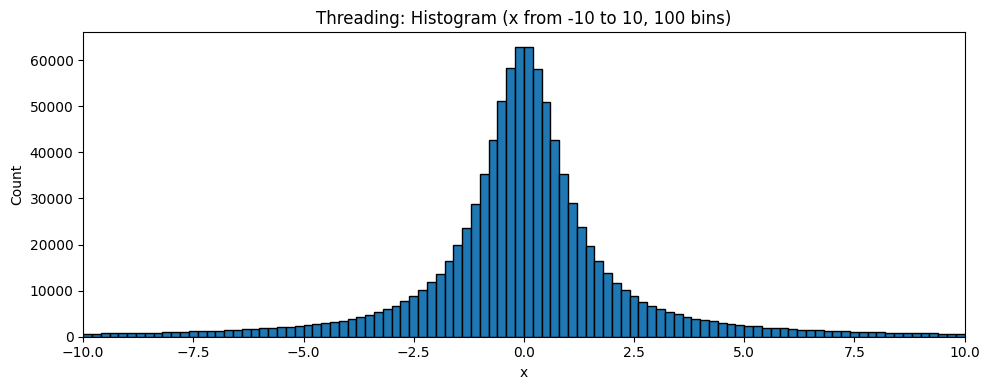

In [49]:
import thread_lorentz

n = 1e6
method_name = "Threading"
# Get counts for histogram from one execution
local_counts, _ = thread_lorentz.run_threaded(n, n_threads=1,)
plot_histogram(local_counts, method_name=method_name)


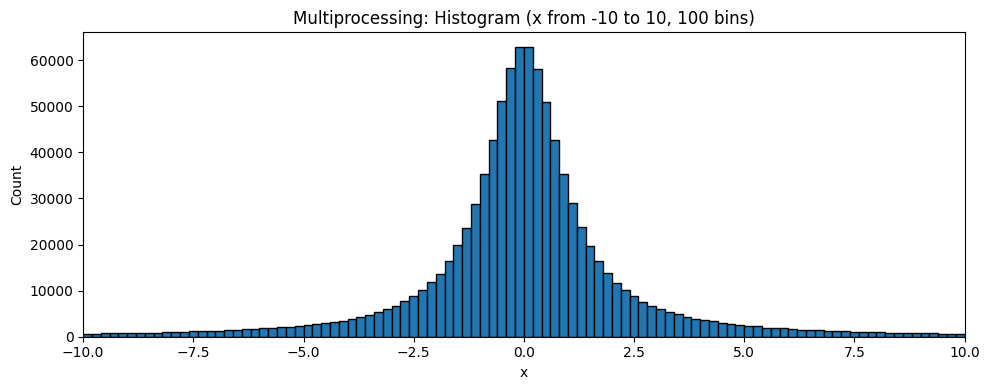

In [50]:
import mp_lorentz

n = 1e6
method_name = "Multiprocessing"
# Get counts for histogram from one execution
local_counts = mp_lorentz.run_multiproc(n, n_cores=1)
plot_histogram(local_counts, method_name=method_name)


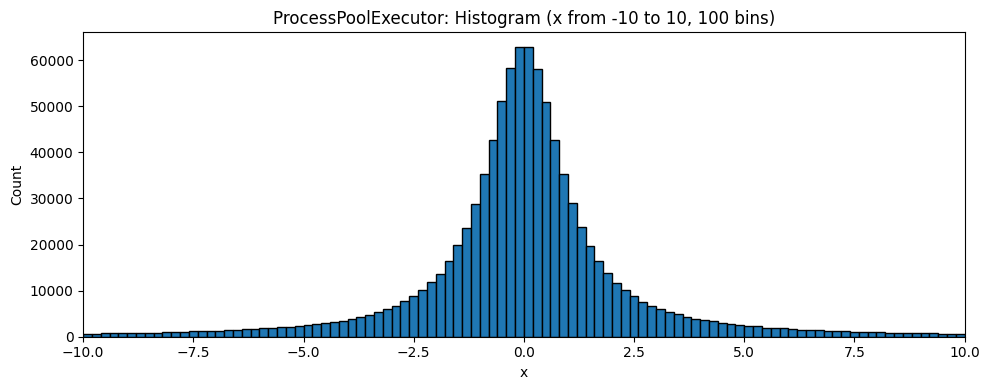

In [51]:
import ppe_lorentz

n = 1e6
method_name = "ProcessPoolExecutor"
# Get counts for histogram from one execution
local_counts = ppe_lorentz.run_ppe(n, max_workers=1)
plot_histogram(local_counts, method_name=method_name)

Results shapes: (1, 100)


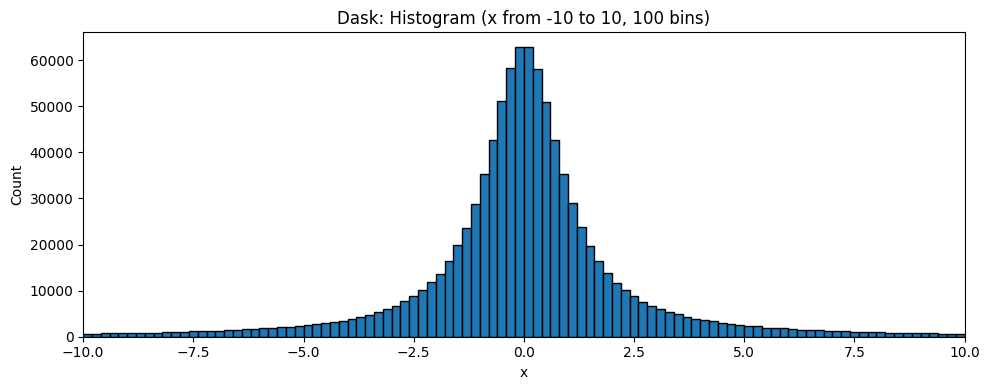

In [52]:
import dask_lorentz

n= 1e6
method_name = "Dask"
# Get counts for histogram from one execution
local_counts = dask_lorentz.run_dask(n, n_tasks=1)
plot_histogram(local_counts, method_name=method_name)

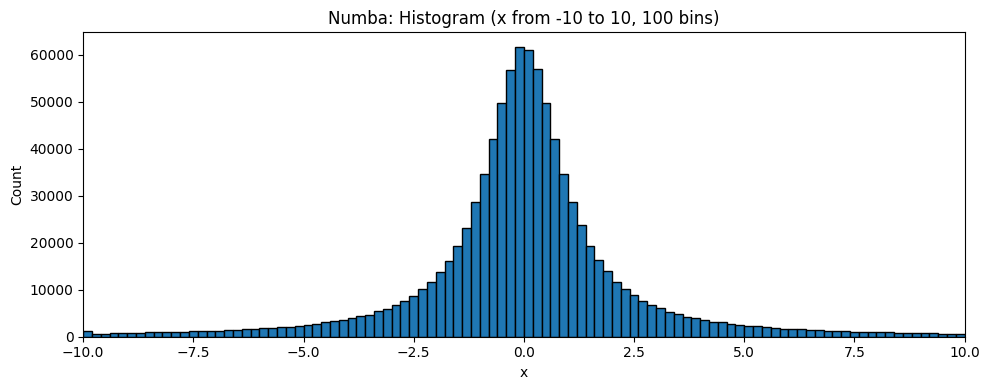

In [53]:
import numba_lorentz
n = 1e6
method_name = "Numba"
# Get counts for histogram from one execution
local_counts = numba_lorentz.lorentzian_histogram_numba(n)
plot_histogram(local_counts, method_name=method_name)

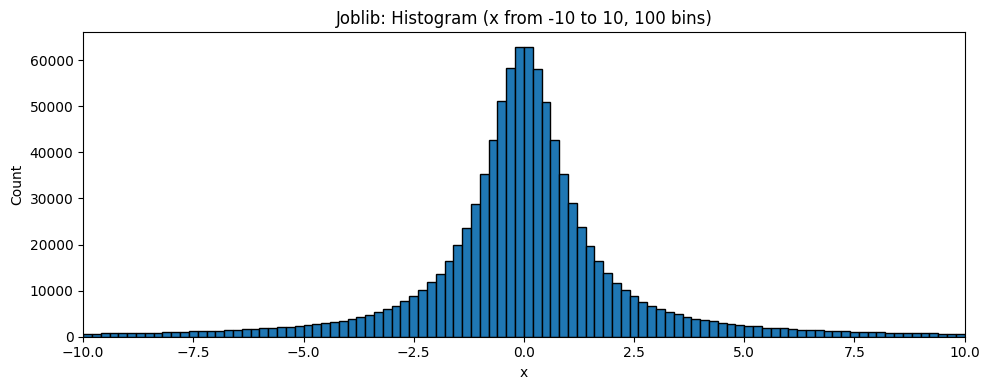

In [54]:
import joblib_lorentz

n = 1e6
method_name = "Joblib"
# Get counts for histogram from one execution
local_counts = joblib_lorentz.run_joblib(n, n_jobs=1)
plot_histogram(local_counts, method_name=method_name)

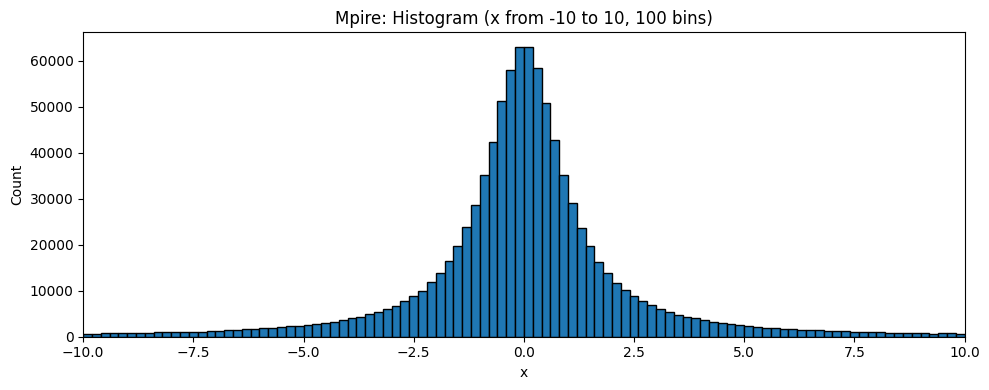

In [55]:
import mpire_lorentz
n = 1e6
method_name = "Mpire"
# Get counts for histogram from one execution
local_counts = mpire_lorentz.run_mpire(n, n_jobs=1)
plot_histogram(local_counts, method_name=method_name)

# Threading

Time taken with 1 threads: 0.1960 ± 0.0136 seconds
Time taken with 2 threads: 0.1279 ± 0.0062 seconds
Time taken with 4 threads: 0.0924 ± 0.0055 seconds
Time taken with 8 threads: 0.0879 ± 0.0026 seconds
Time taken with 16 threads: 0.0927 ± 0.0110 seconds
Time taken with 32 threads: 0.0896 ± 0.0035 seconds


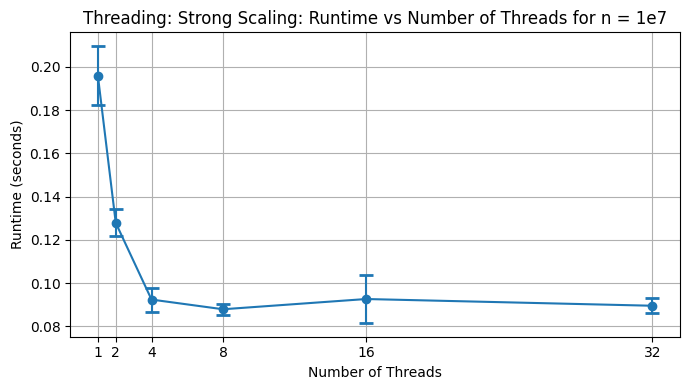

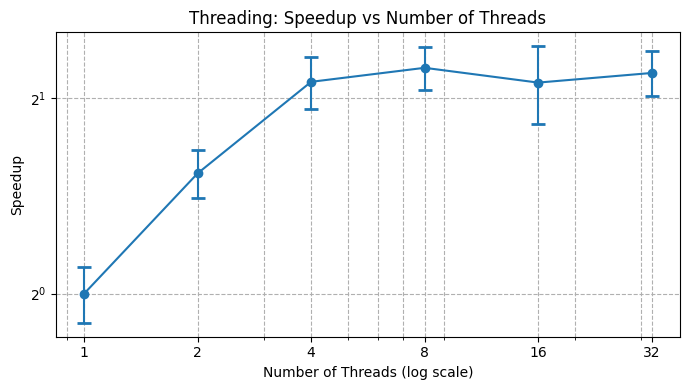

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/255864111.py:40: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


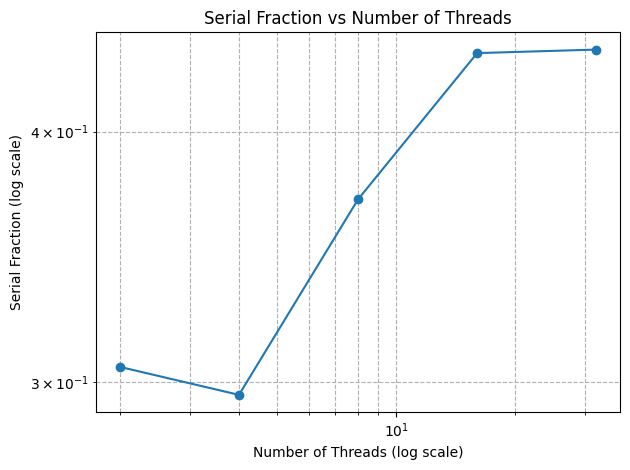

In [56]:
import timeit
import thread_lorentz 
#Strong Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
local_dry_run = thread_lorentz.run_threaded(1e6, n_threads=1)  # Warmup run to initialize threading
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        thread_lorentz.run_threaded(n, n_threads=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")


#plot run time vs parallelism
plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="Threading")

#plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Threading")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)

serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.2082 ± 0.0154 seconds
Time taken with 2 threads: 0.1314 ± 0.0064 seconds
Time taken with 4 threads: 0.1308 ± 0.0387 seconds
Time taken with 8 threads: 0.0972 ± 0.0203 seconds


/Users/a.n.d./Documents/UTD/Coursework/HPC/utd-hpc-course-repo/hw4/src/lorentzian.py:11: RuntimeWarning: divide by zero encountered in divide
  x = 1. / np.tan(np.pi * u) # x = 1/tan(pi*u)


Time taken with 16 threads: 0.1146 ± 0.0235 seconds


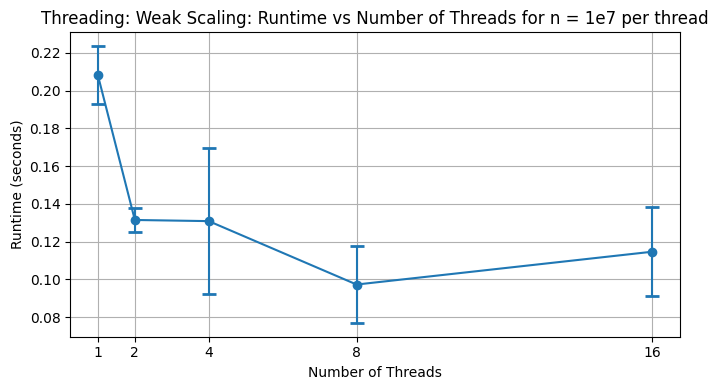

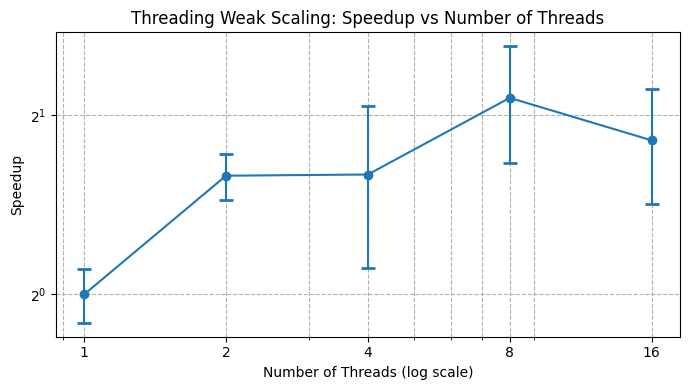

In [57]:
#Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        thread_lorentz.run_threaded(n*n_threads, n_threads=n_threads)
        end = timeit.default_timer()
        run_times.append((end - start) / n_threads)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="Threading")

#plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Threading Weak Scaling")


# Multiprocessing module

Time taken with 1 threads: 2.6405 ± 0.5448 seconds
Time taken with 2 threads: 1.1871 ± 0.2468 seconds
Time taken with 4 threads: 0.7443 ± 0.1479 seconds
Time taken with 8 threads: 0.6785 ± 0.1279 seconds
Time taken with 16 threads: 0.8755 ± 0.1475 seconds
Time taken with 32 threads: 1.3288 ± 0.2643 seconds


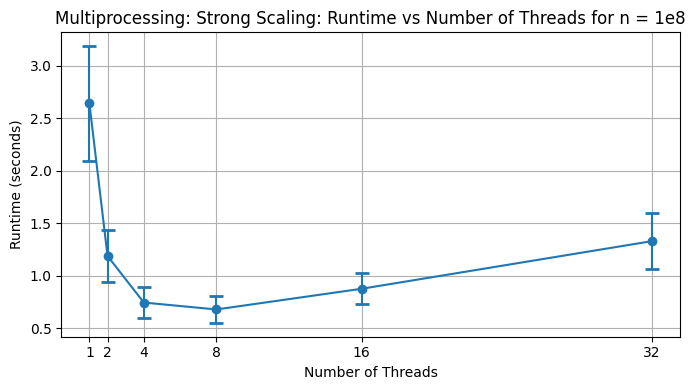

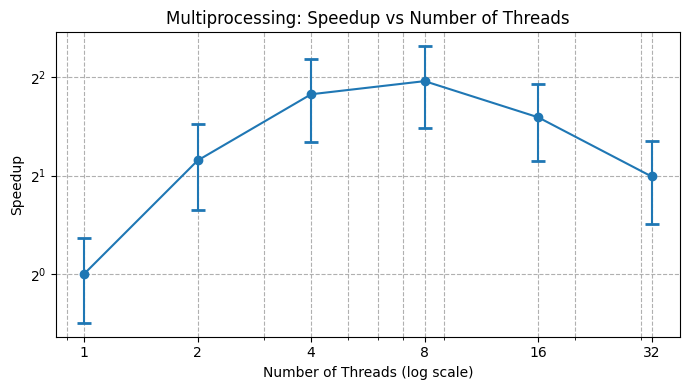

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/4156262355.py:39: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


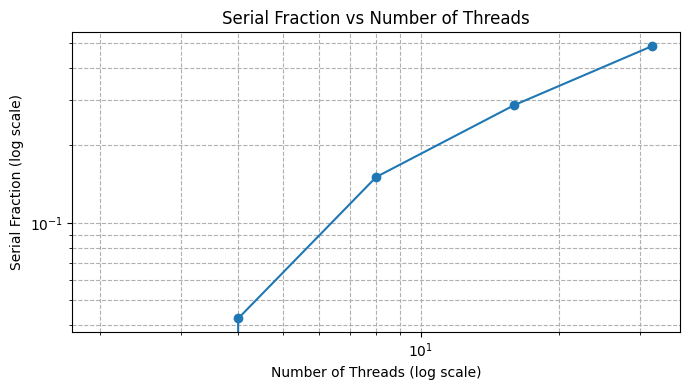

In [70]:
import mp_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e8
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
#Warmup run to initialize multiprocessing
local_counts = mp_lorentz.run_multiproc(1e6, n_cores=1)
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        mp_lorentz.run_multiproc(n, n_cores=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="Multiprocessing")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Multiprocessing")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.2566 ± 0.0045 seconds
Time taken with 2 threads: 0.2613 ± 0.0018 seconds
Time taken with 4 threads: 0.3140 ± 0.0453 seconds


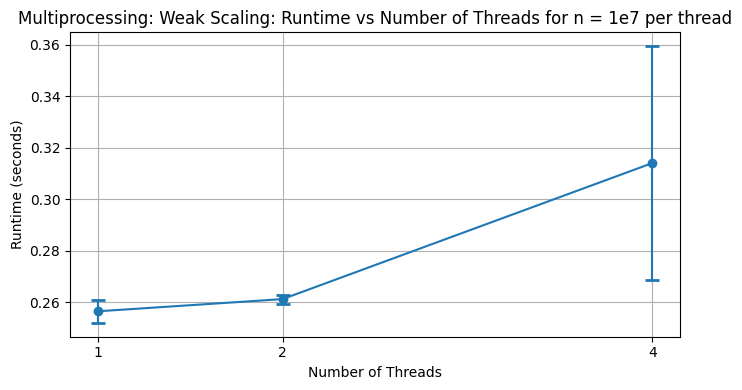

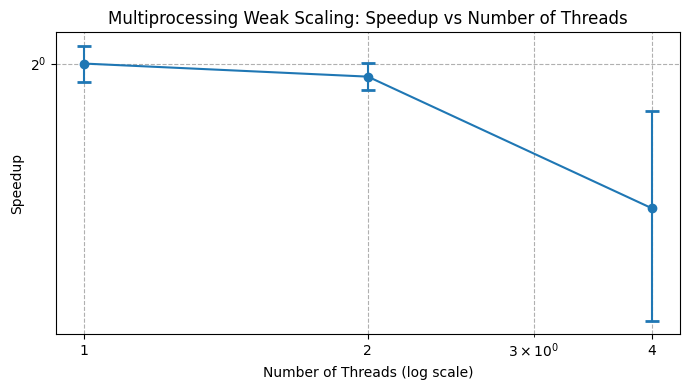

In [59]:
#Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4]
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        mp_lorentz.run_multiproc(n*n_threads, n_cores=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="Multiprocessing")
# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Multiprocessing Weak Scaling")



# ProcessPoolExecutor

Time taken with 1 threads: 0.2868 ± 0.0283 seconds
Time taken with 2 threads: 0.1872 ± 0.0036 seconds
Time taken with 4 threads: 0.1607 ± 0.0041 seconds
Time taken with 8 threads: 0.2159 ± 0.0040 seconds
Time taken with 16 threads: 0.3387 ± 0.0308 seconds
Time taken with 32 threads: 0.3378 ± 0.0425 seconds


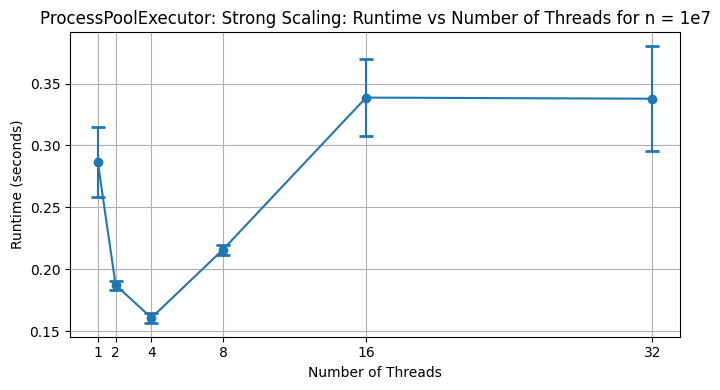

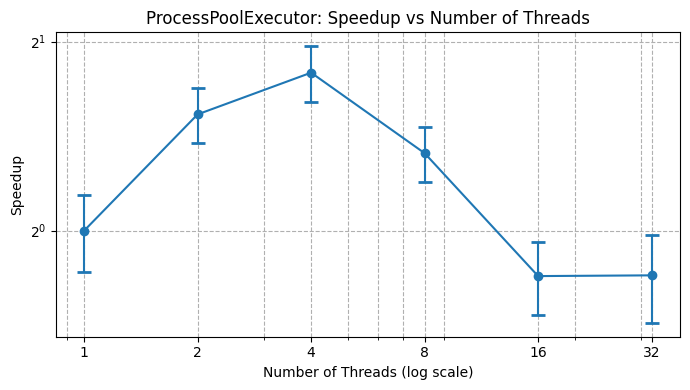

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/101003739.py:40: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


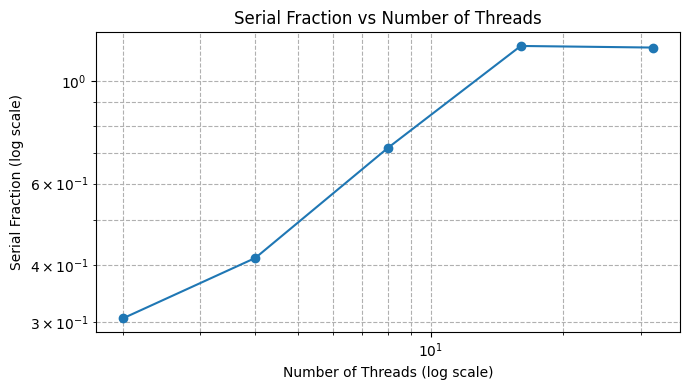

In [71]:
import ppe_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
#Warmup run to initialize multiprocessing
local_dry_run = ppe_lorentz.run_ppe(1e6, max_workers=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        ppe_lorentz.run_ppe(n, max_workers=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="ProcessPoolExecutor")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="ProcessPoolExecutor")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.2653 ± 0.0066 seconds
Time taken with 2 threads: 0.2781 ± 0.0056 seconds
Time taken with 4 threads: 0.3203 ± 0.0233 seconds


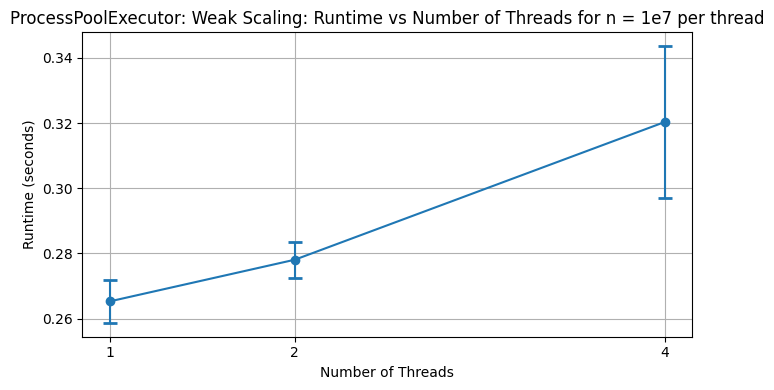

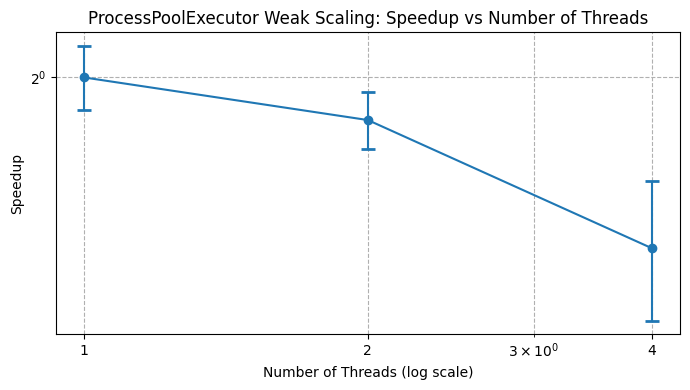

In [61]:
#Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4]
#Warmup run to initialize multiprocessing
local_dry_run = ppe_lorentz.run_ppe(1e6, max_workers=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        ppe_lorentz.run_ppe(n*n_threads, max_workers=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="ProcessPoolExecutor")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="ProcessPoolExecutor Weak Scaling")


# Asyncio

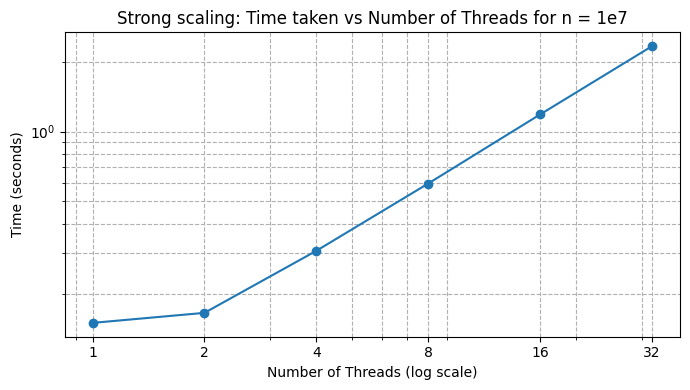

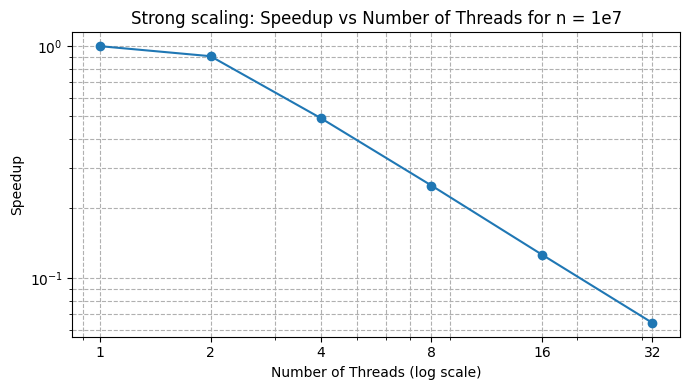

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/1660815283.py:39: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


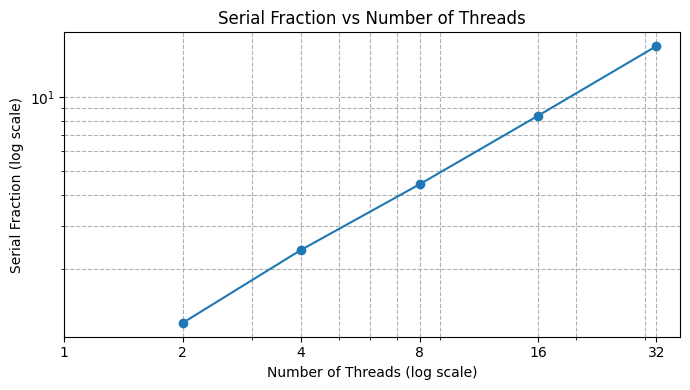

In [72]:
import matplotlib.pyplot as plt

data = np.loadtxt("async_lorentzian_strong_scaling_times.txt")
thread_counts = data[:, 0].astype(int)
times = data[:, 1]
#plot runtime vs parallelism

plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Amdahl serial fraction (undefined for p=1, keep as NaN)
p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

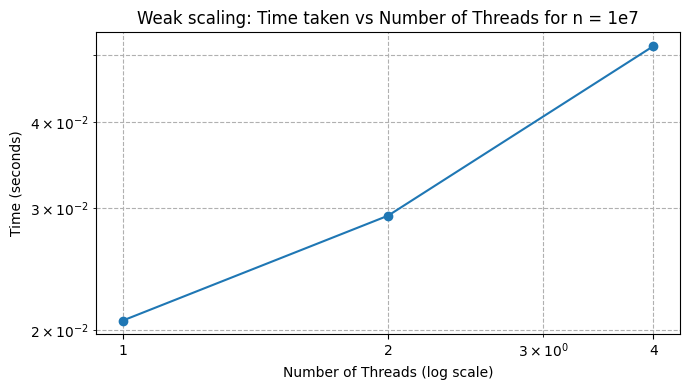

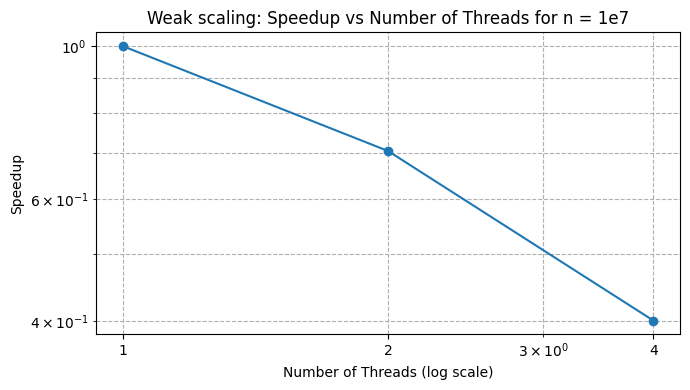

In [73]:
#Weak Scaling
data = np.loadtxt("async_lorentzian_weak_scaling_times.txt")
thread_counts = data[:, 0].astype(int)
times = data[:, 1]
#plot runtime vs parallelism
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Dask

Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Time taken with 1 threads: 0.2562 ± 0.0814 seconds
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Time taken with 2 threads: 0.1441 ± 0.0085 seconds
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Time taken with 4 threads: 0.1082 ± 0.0087 seconds
Results shapes: (8, 100)
Results shapes: (8, 100)
Results shapes: (8, 100)
Results shapes: (8, 100)
Results shapes: (8, 100)
Time taken with 8 threads: 0.1059 ± 0.0054 seconds
Results shapes: (16, 100)
Results shapes: (16, 100)
Results shapes: (16, 100)
Results shapes: (16, 100)
Results shapes: (16, 100)
Time taken with 16 threads: 0.0992 ± 0.0071 seconds
Results shapes: (32, 100)
Results shapes: (32, 100)
Results shapes: (32, 100)
Results sha

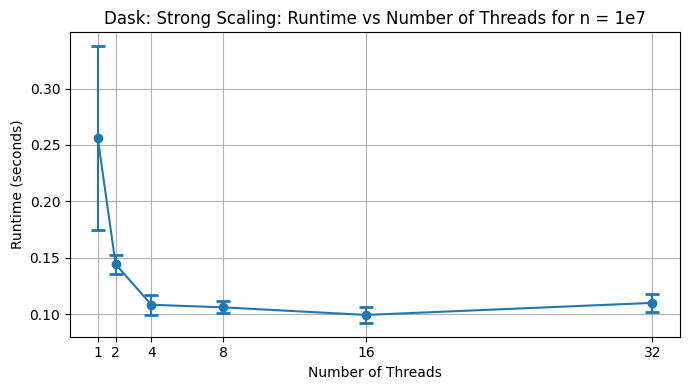

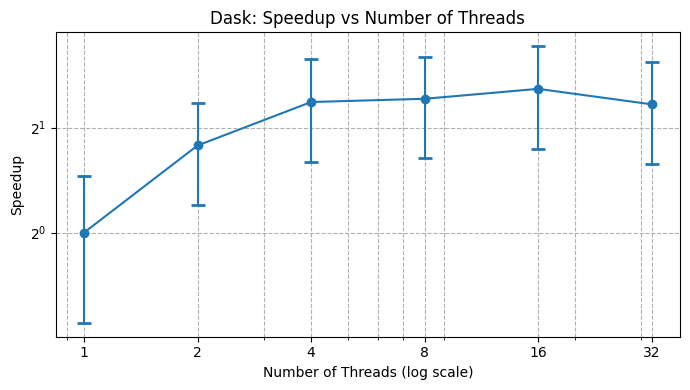

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/2653800036.py:40: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


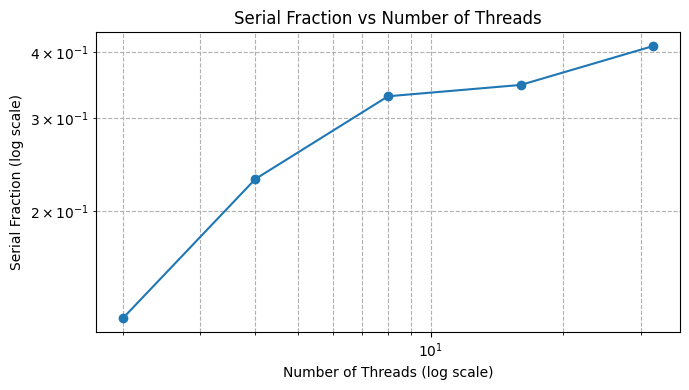

In [75]:
import dask_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
#WARMUP RUN
local_dry_run = dask_lorentz.run_dask(n, n_tasks=1)  # Warmup run to initialize Dask
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        dask_lorentz.run_dask(n, n_tasks=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="Dask")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Dask")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Time taken with 1 threads: 0.1800 ± 0.0025 seconds
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Time taken with 2 threads: 0.2374 ± 0.0051 seconds
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Time taken with 4 threads: 0.3662 ± 0.0094 seconds


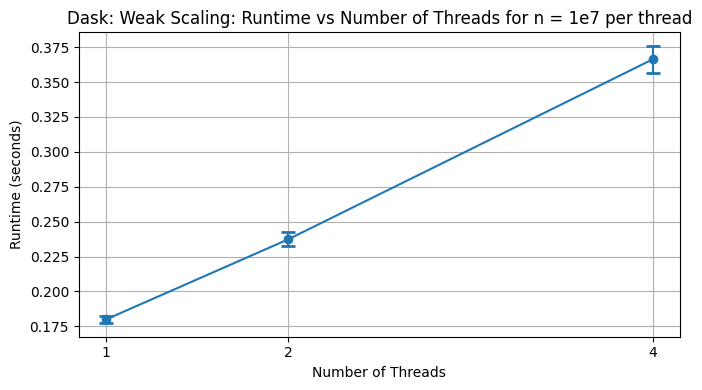

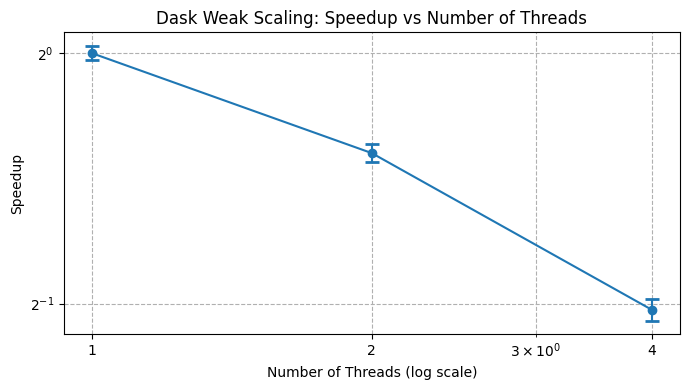

In [65]:
# Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize Dask
local_dry_run = dask_lorentz.run_dask(n, n_tasks=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        dask_lorentz.run_dask(n*n_threads, n_tasks=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="Dask")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Dask Weak Scaling")


# joblib

Time taken with 1 threads: 0.2244 ± 0.0387 seconds
Time taken with 2 threads: 0.2162 ± 0.2309 seconds
Time taken with 4 threads: 0.1543 ± 0.1210 seconds
Time taken with 8 threads: 0.1167 ± 0.1174 seconds
Time taken with 16 threads: 0.1137 ± 0.0507 seconds
Time taken with 32 threads: 0.2714 ± 0.3303 seconds


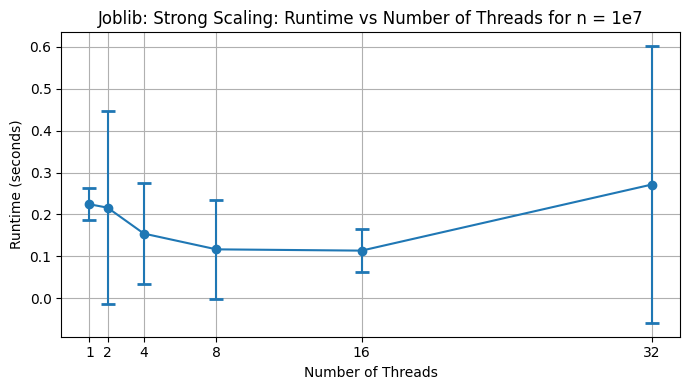

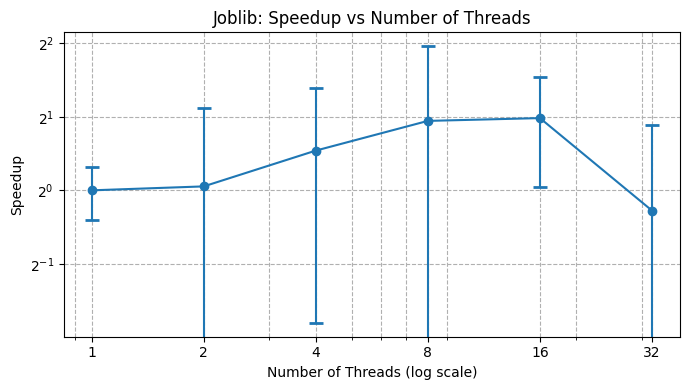

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/709579121.py:40: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


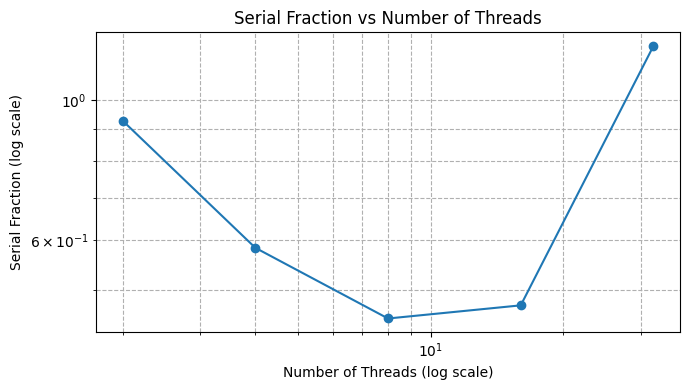

In [77]:
import joblib_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
#WARMUP RUN
local_dry_run = joblib_lorentz.run_joblib(1e7, n_jobs=1)  # Warmup run to initialize Joblib
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        joblib_lorentz.run_joblib(n, n_jobs=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="Joblib")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Joblib")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.1873 ± 0.0024 seconds
Time taken with 2 threads: 0.2487 ± 0.1073 seconds
Time taken with 4 threads: 0.2847 ± 0.0983 seconds


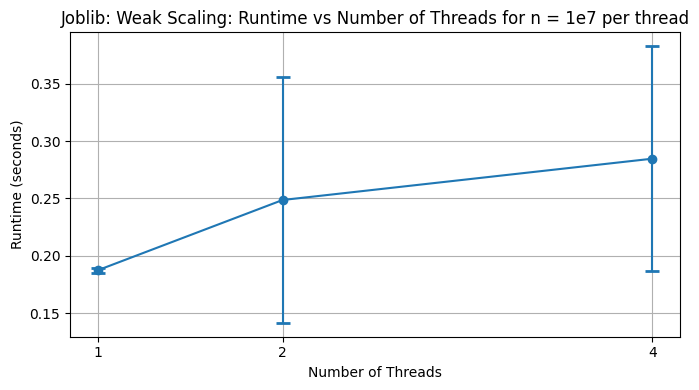

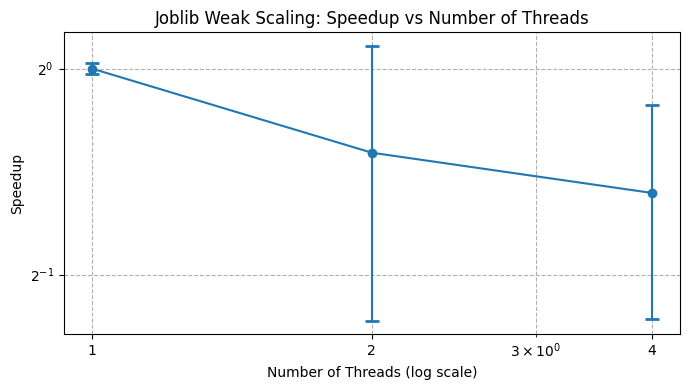

In [67]:
# Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize Joblib
local_dry_run = joblib_lorentz.run_joblib(n, n_jobs=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        joblib_lorentz.run_joblib(n*n_threads, n_jobs=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="Joblib")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Joblib Weak Scaling")


# mpire

Time taken with 1 threads: 0.3167 ± 0.0022 seconds
Time taken with 2 threads: 0.2425 ± 0.0487 seconds
Time taken with 4 threads: 0.1674 ± 0.0600 seconds
Time taken with 8 threads: 0.1520 ± 0.0488 seconds
Time taken with 16 threads: 0.1699 ± 0.0479 seconds
Time taken with 32 threads: 0.2569 ± 0.0936 seconds


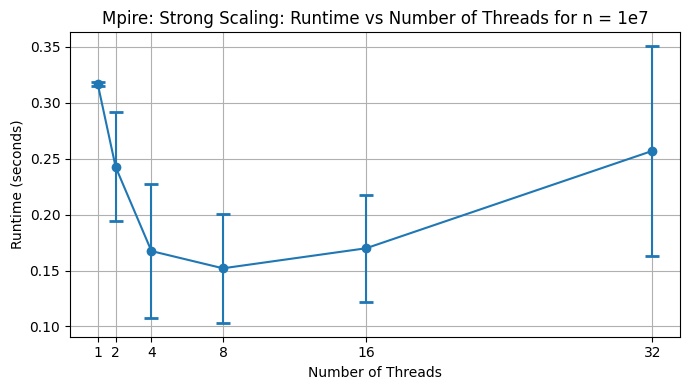

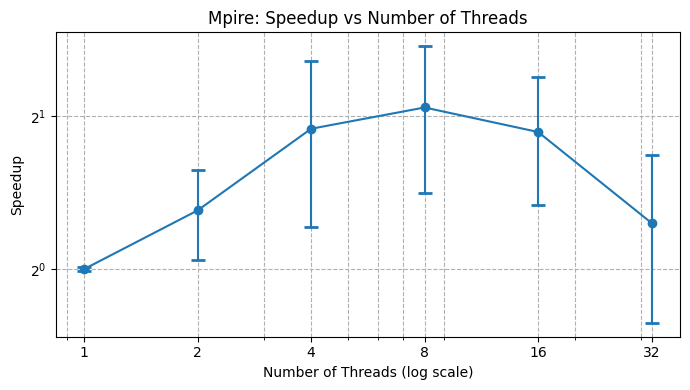

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_45172/1014204639.py:43: RuntimeWarning: invalid value encountered in divide
  (1/s - 1/p) / (1 - 1/p),


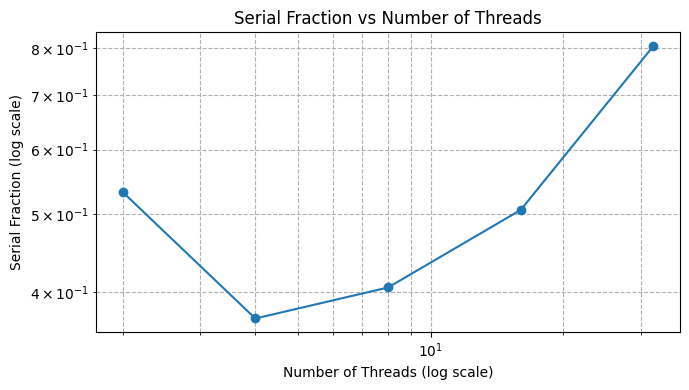

In [79]:
import importlib
import mpire_lorentz
importlib.reload(mpire_lorentz)
import timeit

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4, 8, 16, 32]
#WARMUP RUN
local_dry_run = mpire_lorentz.run_mpire(1e7, n_jobs=1)  # Warmup run to initialize mpire
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        mpire_lorentz.run_mpire(n, n_jobs=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_strong_scaling(n, thread_counts, times, errors=errors, method_name="Mpire")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Mpire")

p = np.array(thread_counts, dtype=float)
s = np.array(speedup, dtype=float)

# Amdahl serial fraction (undefined for p=1, keep as NaN)
serial_fraction = np.where(
    p > 1,
    (1/s - 1/p) / (1 - 1/p),
    np.nan
)
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, serial_fraction, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Serial Fraction (log scale)')
plt.title('Serial Fraction vs Number of Threads')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.3213 ± 0.0024 seconds
Time taken with 2 threads: 0.3261 ± 0.0024 seconds
Time taken with 4 threads: 0.3299 ± 0.0037 seconds


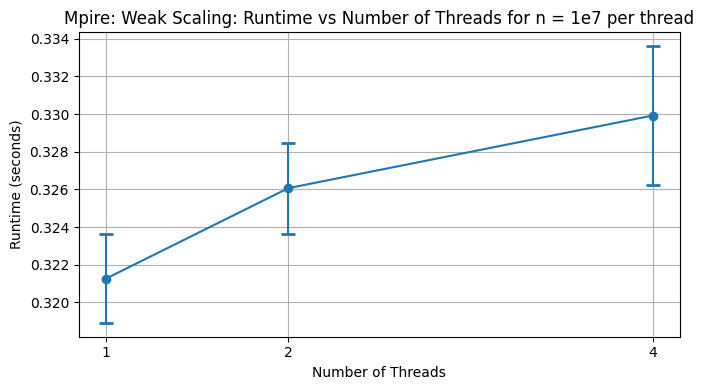

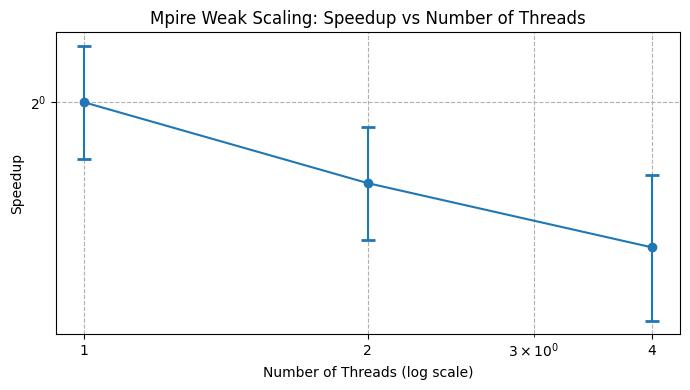

In [69]:
# Weak Scaling
n=1e7
times=[]
errors=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize mpire
local_dry_run = mpire_lorentz.run_mpire(n, n_jobs=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    run_times = []
    for _ in range(5):
        start = timeit.default_timer()
        mpire_lorentz.run_mpire(n*n_threads, n_jobs=n_threads)
        end = timeit.default_timer()
        run_times.append(end - start)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    times.append(avg_time)
    errors.append(std_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} ± {std_time:.4f} seconds")

plot_weak_scaling(n, thread_counts, times, errors=errors, method_name="Mpire")

# plot speedup vs parallelism
speedup = [times[0] / t for t in times]
speedup_errors = [speedup[i] * np.sqrt((errors[i]/times[i])**2 + (errors[0]/times[0])**2) for i in range(len(times))]
plot_speedup(thread_counts, speedup, speedup_errors=speedup_errors, method_name="Mpire Weak Scaling")
